# Serverless RL on Kimi K3: Countdown

A single-turn, programmatic-reward counterpart to the text-to-SQL and human-sounding notebooks. Same serverless loop — **rollout → reward → weight update** — on the [Countdown numbers task](https://en.wikipedia.org/wiki/Countdown_(game_show)#Numbers_round): given source numbers and a target, write an arithmetic expression using each number exactly once.

We LoRA-tune **Kimi K3** (2.8T MoE) with a **deterministic composite reward** (well-formed `<answer>`, correct numbers, hits target). No tools, no external API — the smallest honest RL loop after the script in `training/examples/serverless_rl/countdown_rl.py`.

The loop, one step (repeats every optimizer step):

```
save_weights_for_sampler        (snapshot current adapter)
        |
        v
create_sampling_client          (sampler bound to that snapshot)
        |
        v
sample GROUP_SIZE equations per prompt   (rollout)
        |
        v
composite_reward (format + numbers + target)
        |
        v
group-relative advantages (GRPO)
        |
        v
importance-sampling datums
        |
        v
forward_backward  ->  optim_step   (update the adapter)
        |
        └──────────────► back to top (next step)
```

> Defaults match the [K3 LoRA Countdown run](https://fireworks.ai/blog/K3-LoRA-Training): 20 steps, 8 samples per prompt, LR `2.5e-5`. The bundled 32-row JSONL is enough to reproduce the curve shape; point `DATASET` at a larger file for production-quality runs (~860K training tokens).

## 1. Setup

```bash
pip install --pre "fireworks-ai[training]" transformers python-dotenv matplotlib
export FIREWORKS_API_KEY=fw_...
```

Kimi K3 ships its chat template in Python (no Jinja), so we register the cookbook's K3 renderer from `training/renderer/kimi_k3.py`. Launch this notebook from anywhere in the repo.

In [ ]:
import json
import math
import os
import random
import sys
from pathlib import Path

import tinker
from fireworks.training.sdk import FiretitanServiceClient
from tinker_cookbook.renderers import get_renderer, get_text_content
from transformers import AutoTokenizer

try:
    from dotenv import load_dotenv

    load_dotenv()
except ImportError:
    pass

# Register the cookbook K3 renderer.
_HERE = Path.cwd()
_REPO_ROOT = next(
    (p for p in [_HERE, *_HERE.parents] if (p / "training" / "renderer" / "kimi_k3.py").exists()),
    None,
)
assert _REPO_ROOT is not None, "could not locate training/renderer/kimi_k3.py -- run inside the cookbook repo"
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))
import training.renderer.kimi_k3  # noqa: F401  registers "kimi_k3" / "kimi_k3_disable_thinking"

RUN_DIR = _HERE if (_HERE / "serverless_countdown_rl.ipynb").exists() else _REPO_ROOT

API_KEY = os.environ.get("FIREWORKS_API_KEY", "")
assert API_KEY, "set FIREWORKS_API_KEY"

# --- what to train -----------------------------------------------------------
BASE_MODEL = "accounts/fireworks/models/kimi-k3"
TOKENIZER = "moonshotai/Kimi-K3"
RENDERER = "kimi_k3"           # matches dataset format (<think> + <answer>)
LORA_RANK = 8

# --- RL loop shape (aligned with blog + countdown_rl.py) --------------------
STEPS = 20
PROMPT_GROUPS_PER_STEP = 8   # Countdown prompts per step (one GRPO group each)
GROUP_SIZE = 8               # completions sampled per prompt (GRPO group)
PROMPT_CONCURRENCY = 4       # sample() calls in flight (K3 is latency-bound)
MAX_SAMPLE_TOKENS = 4096
TEMPERATURE = 1.0
LEARNING_RATE = 2.5e-5       # countdown_rl.py default; 5e-6 was too conservative for K3
MAX_SEQ_LEN = 65536
SAMPLING_TIMEOUT_S = 1800.0

# --- data --------------------------------------------------------------------
DATASET = _REPO_ROOT / "training/examples/serverless_rl/data/countdown_train.jsonl"
N_HOLDOUT = 8                # last N rows -> fixed eval set
print("config ready")

/Users/sinan/cookbook-casestudies/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


config ready


## 2. Connect to the serverless session

One `FiretitanServiceClient` on `/training/v1/serverless` gives both the LoRA training client and (later) samplers. K3's tokenizer needs `trust_remote_code=True`.

In [2]:
def _serverless_base_url(base_url: str) -> str:
    root = base_url.rstrip("/")
    if root.endswith("/training/v1/serverless"):
        return root
    if root.endswith("/training/v1"):
        return f"{root}/serverless"
    return f"{root}/training/v1/serverless"


api_base = os.environ.get("FIREWORKS_BASE_URL", "https://api.fireworks.ai")
service = FiretitanServiceClient(api_key=API_KEY, base_url=_serverless_base_url(api_base))
training_client = service.create_lora_training_client(base_model=BASE_MODEL, rank=LORA_RANK)

tokenizer = AutoTokenizer.from_pretrained(TOKENIZER, trust_remote_code=True)
renderer = get_renderer(RENDERER, tokenizer)

print(
    f"session={getattr(service, 'training_session_id', None)} "
    f"run={getattr(training_client, 'run_id', None)}\n"
    f"base_model={BASE_MODEL} renderer={RENDERER} rank={LORA_RANK}"
)

session=ts-7b71e8bdafa54f13985f10e4bb2c6147 run=run-d89890b42775438b8331a130d11e7c9c
base_model=accounts/fireworks/models/kimi-k3 renderer=kimi_k3 rank=8


## 3. Data

Each row is `{"messages": [...], "ground_truth": {"numbers": [...], "target": N}}`. The bundled 32-row sample lives in `training/examples/serverless_rl/data/countdown_train.jsonl`. We hold out the last `N_HOLDOUT` rows for a fixed eval curve.

In [3]:
assert DATASET.exists(), f"dataset not found: {DATASET}"

rows = [json.loads(line) for line in DATASET.open() if line.strip()]
assert rows, f"dataset is empty: {DATASET}"

train_rows = rows[:-N_HOLDOUT]
holdout_rows = rows[-N_HOLDOUT:]
random.seed(0)
data_order = list(range(len(train_rows)))
random.shuffle(data_order)

print(f"loaded {len(rows)} rows | train={len(train_rows)} holdout={len(holdout_rows)}")

loaded 32 rows | train=24 holdout=8


In [14]:
train_rows[0]

{'messages': [{'role': 'system',
   'content': 'You are a math puzzle solver. Given a target number and a set of available numbers, find an arithmetic expression using each number exactly once with operations +, -, *, / to reach the target.\n\nShow your reasoning inside <think>...</think> tags, then put your final equation inside <answer>...</answer> tags.\n\nExample:\nTarget: 24, Numbers: [1, 2, 3, 4]\n<think>I need to reach 24. Let me try 1 * 2 * 3 * 4 = 24.</think>\n<answer>1 * 2 * 3 * 4</answer>'},
  {'role': 'user',
   'content': 'Using the numbers [45, 14, 39], create an equation that equals 20. You can use +, -, *, / and each number must be used exactly once.'}],
 'ground_truth': '{"numbers": [45, 14, 39], "target": 20}'}

## 4. Reward: composite Countdown score

Partial credit so RL has signal from a cold start:

- **+0.1** for a parseable `<answer>...</answer>`
- **+0.2** for using exactly the source numbers
- **+0.7** for an expression that evaluates to the target

Same shaping as `training/examples/serverless_rl/countdown_rewards.py`.

In [ ]:
import re


def _extract_answer(text: str) -> str | None:
    """Extract the answer from the text."""
    matches = list(re.finditer(r"<answer>(.*?)</answer>", text, flags=re.IGNORECASE | re.DOTALL))
    return matches[-1].group(1).strip() if matches else None


def _safe_eval_equation(equation: str) -> float | None:
    cleaned = equation.replace(" ", "")
    if not re.match(r"^[\d+\-*/().]+$", cleaned):
        return None
    if "**" in cleaned or "//" in cleaned:
        return None
    try:
        return float(eval(cleaned, {"__builtins__": None}, {}))  # noqa: S307
    except Exception:
        return None


def _check_numbers_used(equation: str, numbers: list[int]) -> bool:
    used = sorted(int(x) for x in re.findall(r"\d+", equation))
    return used == sorted(numbers)


def _parse_ground_truth(ground_truth: str | dict) -> tuple[list[int], int]:
    """Parse the ground truth from the JSONL row."""
    gt = json.loads(ground_truth) if isinstance(ground_truth, str) else ground_truth
    numbers = gt.get("numbers") or gt.get("nums")
    if numbers is None:
        raise KeyError("ground_truth must include 'numbers' or 'nums'")
    return list(numbers), int(gt["target"])


def composite_reward(response: str, ground_truth: str | dict) -> float:
    """Composite reward for the Countdown task.

    Partial credit so RL has signal from a cold start:

    - **+0.1** for a parseable `<answer>...</answer>`
    - **+0.2** for using exactly the source numbers
    - **+0.7** for an expression that evaluates to the target
    """
    numbers, target = _parse_ground_truth(ground_truth)
    equation = _extract_answer(response)
    if equation is None:
        return 0.0
    score = 0.1
    numbers_valid = _check_numbers_used(equation, numbers)
    if numbers_valid:
        score += 0.2
    result = _safe_eval_equation(equation)
    if numbers_valid and result is not None and abs(result - target) < 1e-6:
        score += 0.7
    return score


print("reward defined")

reward defined


## 5. RL primitives

**GRPO:** standardize rewards within each prompt group to `(r - mean) / std`. Drop groups with no spread.

**Datum:** shifted next-token layout for importance sampling — `model_input` is prompt + all-but-last sampled token; advantages apply only over the response region.

In [ ]:
def group_relative_advantages(rewards, eps=1e-8):
    """An implementation of Group-Relative Policy Optimization (GRPO).

    This function calculates group-relative advantages for a list of rewards.
    It standardizes the rewards within each group by subtracting the mean and dividing by the standard deviation.
    This helps in stabilizing the policy updates and improving the convergence of the RL algorithm. 
    It also adds a small epsilon to the denominator to avoid division by zero.

    Args:
        rewards (list): A list of rewards for each group.
        eps (float): A small epsilon value to avoid division by zero.

    Returns:
        list: A list of group-relative advantages for each group.
    """
    if len(rewards) <= 1:
        return [0.0 for _ in rewards]
    mean = sum(rewards) / len(rewards)
    var = sum((r - mean) ** 2 for r in rewards) / (len(rewards) - 1)
    std = math.sqrt(var)
    if std < eps:
        std = 1.0
    return [(r - mean) / (std + eps) for r in rewards]


def make_datum(prompt, tokens, logprobs, advantage):
    """Create a tinker.Datum object for the given prompt, tokens, logprobs, and advantage.

    This function constructs a tinker.Datum object that contains the model input and loss function inputs.
    The model input is created by appending the tokens to the prompt.
    The loss function inputs include the target tokens, log probabilities, and advantages.
    """
    response_start = prompt.length - 1
    model_input = prompt.append(tinker.EncodedTextChunk(tokens=tokens[:-1]))
    return tinker.Datum(
        model_input=model_input,
        loss_fn_inputs={
            "target_tokens": [0] * response_start + tokens,
            "logprobs": [0.0] * response_start + logprobs,
            "advantages": [0.0] * response_start
            + [advantage] * (model_input.length - response_start),
        },
    )

## 6. Rollout + scoring

Single-turn: render the chat prompt, sample `GROUP_SIZE` completions in one `sample()` call per prompt (efficient for GRPO grouping). Decode each completion and score with `composite_reward`.

In [6]:
def sample_group(sampler, row):
    """Sample GROUP_SIZE completions for one Countdown prompt."""
    prompt = renderer.build_generation_prompt(row["messages"])
    if prompt.length + MAX_SAMPLE_TOKENS > MAX_SEQ_LEN:
        return None, []
    params = tinker.SamplingParams(
        max_tokens=MAX_SAMPLE_TOKENS,
        temperature=TEMPERATURE,
        stop=renderer.get_stop_sequences(),
    )
    fut = sampler.sample(prompt=prompt, num_samples=GROUP_SIZE, sampling_params=params)
    result = fut.result(timeout=SAMPLING_TIMEOUT_S) if hasattr(fut, "result") else fut

    samples = []
    for seq in getattr(result, "sequences", []) or []:
        tokens = list(getattr(seq, "tokens", []) or [])
        logprobs = getattr(seq, "logprobs", None)
        if not tokens or logprobs is None or len(logprobs) != len(tokens):
            continue
        content = get_text_content(renderer.parse_response(tokens)[0])
        reward = float(composite_reward(content, row["ground_truth"]))
        samples.append({
            "prompt": prompt,
            "tokens": tokens,
            "logprobs": [float(x) for x in logprobs],
            "text": content,
            "reward": reward,
        })
    return prompt, samples


def rollout_batch(sampler, batch_rows):
    """Roll out every row in batch_rows, PROMPT_CONCURRENCY sample() calls in flight."""
    from concurrent.futures import ThreadPoolExecutor

    chunk = max(1, PROMPT_CONCURRENCY)
    groups = []
    with ThreadPoolExecutor(max_workers=chunk) as ex:
        for start in range(0, len(batch_rows), chunk):
            slice_rows = batch_rows[start : start + chunk]
            for _prompt, samples in ex.map(lambda r: sample_group(sampler, r), slice_rows):
                groups.append(samples)
    return groups


print("rollout + scoring defined")

rollout + scoring defined


## 7. The RL loop

Each step: snapshot → sampler → roll out training batch + fixed holdout → GRPO advantages → `forward_backward` + `optim_step`.

We track two metrics (the blog chart is closer to **solve rate** — fraction of samples scoring exactly `1.0` — than mean composite reward, which stays elevated at `0.3` when numbers are right but the target is wrong).

In [7]:
EVAL_EVERY = 2
eval_track_rows = holdout_rows


def solve_rate(rewards):
    """Fraction of completions with composite_reward == 1.0 (blog 'solve rate')."""
    if not rewards:
        return 0.0
    return sum(1 for r in rewards if r >= 1.0 - 1e-6) / len(rewards)


adam = tinker.AdamParams(learning_rate=LEARNING_RATE, beta1=0.9, beta2=0.95, eps=1e-8, weight_decay=0.0)
history, solve_history = [], []
eval_history, eval_solve_history, eval_steps = [], [], []
cursor = 0
base_snapshot = None
best_eval, best_snapshot, best_step = -1.0, None, -1
best_solve, best_solve_snapshot, best_solve_step = -1.0, None, -1

for step in range(STEPS):
    snapshot = training_client.save_weights_for_sampler(f"countdown-{step:04d}").result().path
    if step == 0:
        base_snapshot = snapshot
    sampler = service.create_sampling_client(model_path=snapshot, tokenizer=tokenizer)

    batch = [train_rows[data_order[(cursor + i) % len(data_order)]] for i in range(PROMPT_GROUPS_PER_STEP)]
    cursor += PROMPT_GROUPS_PER_STEP

    do_eval = (step % EVAL_EVERY == 0) or (step == STEPS - 1)
    try:
        train_groups = rollout_batch(sampler, batch)
        eval_groups = rollout_batch(sampler, eval_track_rows) if do_eval else []
    finally:
        sampler.close()

    datums, raw_rewards, kept_groups = [], [], 0
    for samples in train_groups:
        rewards = [s["reward"] for s in samples]
        raw_rewards.extend(rewards)
        if not rewards or len(set(round(r, 6) for r in rewards)) <= 1:
            continue
        kept_groups += 1
        for sample, adv in zip(samples, group_relative_advantages(rewards)):
            d = make_datum(sample["prompt"], sample["tokens"], sample["logprobs"], adv)
            if d.model_input.length <= MAX_SEQ_LEN:
                datums.append(d)

    if datums:
        training_client.forward_backward(datums, "importance_sampling").result()
        training_client.optim_step(adam).result()

    mean_reward = sum(raw_rewards) / len(raw_rewards) if raw_rewards else 0.0
    train_solve = solve_rate(raw_rewards)
    history.append(mean_reward)
    solve_history.append(train_solve)

    eval_mean = eval_solve = None
    if eval_groups:
        eval_rewards = [s["reward"] for g in eval_groups for s in g]
        eval_mean = sum(eval_rewards) / len(eval_rewards) if eval_rewards else 0.0
        eval_solve = solve_rate(eval_rewards)
        eval_history.append(eval_mean)
        eval_solve_history.append(eval_solve)
        eval_steps.append(step)
        if eval_mean > best_eval:
            best_eval, best_snapshot, best_step = eval_mean, snapshot, step
        if eval_solve > best_solve:
            best_solve, best_solve_snapshot, best_solve_step = eval_solve, snapshot, step

    print(
        f"step {step:02d} train={mean_reward:.3f} solve={train_solve:.1%} "
        f"eval={'n/a' if eval_mean is None else f'{eval_mean:.3f}'} "
        f"eval_solve={'n/a' if eval_solve is None else f'{eval_solve:.1%}'} "
        f"kept_groups={kept_groups}/{len(batch)} datums={len(datums)}"
    )

step 00 train=0.616 solve=59.4% eval=0.606 eval_solve=57.8% kept_groups=8/8 datums=64
step 01 train=0.625 solve=60.9% eval=n/a eval_solve=n/a kept_groups=5/8 datums=40
step 02 train=0.747 solve=71.9% eval=0.677 eval_solve=65.6% kept_groups=7/8 datums=56
step 03 train=0.673 solve=65.6% eval=n/a eval_solve=n/a kept_groups=8/8 datums=64
step 04 train=0.756 solve=75.0% eval=0.692 eval_solve=67.2% kept_groups=5/8 datums=40
step 05 train=0.803 solve=78.1% eval=n/a eval_solve=n/a kept_groups=7/8 datums=56


DeploymentSampler request 648b5dbfc897431fb8a545fe37c646bf: Transient HTTP 503 (attempt 1/7); retrying after 2.5s.


step 06 train=0.756 solve=75.0% eval=0.763 eval_solve=75.0% kept_groups=3/8 datums=24
step 07 train=0.756 solve=75.0% eval=n/a eval_solve=n/a kept_groups=6/8 datums=48
step 08 train=0.942 solve=93.8% eval=0.791 eval_solve=78.1% kept_groups=4/8 datums=32


DeploymentSampler request 86d88c06a12040ddaff15b45548c41df: Transient HTTP 503 (attempt 1/7); retrying after 2.8s.
DeploymentSampler request 634369097d2c4ea79c2f050e5fd0b9b8: Transient HTTP 503 (attempt 1/7); retrying after 2.4s.
DeploymentSampler request a82cff0627464a24bdde6bbde8ea2362: Transient HTTP 503 (attempt 1/7); retrying after 1.9s.
DeploymentSampler request 36b0c5fa6441488aaf02df5dab328748: Transient HTTP 503 (attempt 1/7); retrying after 1.2s.
DeploymentSampler request e78c3ccce0a94afebbe5982ae7adfe72: Transient HTTP 503 (attempt 1/7); retrying after 1.9s.
DeploymentSampler request be9323a84af0420b80e77a28822f67bb: Transient HTTP 503 (attempt 1/7); retrying after 2.2s.
DeploymentSampler request e1974448f1e54059bbb69e1764a143bf: Transient HTTP 503 (attempt 1/7); retrying after 2.8s.


step 09 train=0.739 solve=73.4% eval=n/a eval_solve=n/a kept_groups=5/8 datums=40
step 10 train=0.695 solve=68.8% eval=0.875 eval_solve=87.5% kept_groups=5/8 datums=40
step 11 train=0.986 solve=98.4% eval=n/a eval_solve=n/a kept_groups=1/8 datums=8


...

step 15 train=0.875 solve=87.5% eval=n/a eval_solve=n/a kept_groups=3/8 datums=24


DeploymentSampler request 381341e66d5d4af09dd7a43ffa851108: Transient HTTP 503 (attempt 1/7); retrying after 1.8s.
DeploymentSampler request 6317af02ca2f4100807a2fc6c854dbe4: Transient HTTP 503 (attempt 1/7); retrying after 2.6s.
DeploymentSampler request eafb9cf324a94d9fbb598506c81c480e: Transient HTTP 503 (attempt 1/7); retrying after 2.3s.


step 16 train=0.844 solve=84.4% eval=0.875 eval_solve=87.5% kept_groups=2/8 datums=16
step 17 train=1.000 solve=100.0% eval=n/a eval_solve=n/a kept_groups=0/8 datums=0


DeploymentSampler request 166053b8e4cd4869afa904260913456c: Transient HTTP 503 (attempt 1/7); retrying after 1.0s.
DeploymentSampler request 66495abac9b64b5d80d20016870e7fb2: Transient HTTP 503 (attempt 1/7); retrying after 2.0s.
DeploymentSampler request 4456a552198b42fe8d32d314891a8342: Transient HTTP 503 (attempt 1/7); retrying after 2.7s.
DeploymentSampler request cf56f3a8637648d38c0179f107913c34: Transient HTTP 503 (attempt 1/7); retrying after 1.5s.


step 18 train=0.859 solve=85.9% eval=0.875 eval_solve=87.5% kept_groups=3/8 datums=24
step 19 train=0.891 solve=89.1% eval=0.875 eval_solve=87.5% kept_groups=1/8 datums=8


## 8. Reward curve + save the adapter

Two lines matter: **held-out solve rate** (blog metric — % scoring exactly 1.0) and mean composite reward (includes partial credit at 0.3).

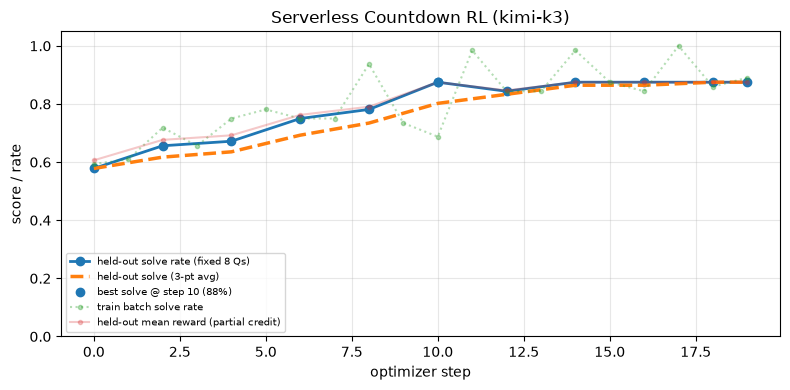

final adapter snapshot: pyroworks/run-d89890b42775438b8331a130d11e7c9c/countdown-final-b686c894
best by solve rate: step 10  solve=87.5%  -> pyroworks/run-d89890b42775438b8331a130d11e7c9c/countdown-0010-b686c894
best by mean reward: step 10  eval=0.875
held-out solve rate: 58% -> 88% (peak 88%)


In [8]:
import matplotlib.pyplot as plt

final = training_client.save_weights_for_sampler("countdown-final").result()
_fs = service.create_sampling_client(model_path=final.path, tokenizer=tokenizer)
try:
    _final_groups = rollout_batch(_fs, eval_track_rows)
finally:
    _fs.close()
_final_rewards = [s["reward"] for g in _final_groups for s in g]
_final_eval = sum(_final_rewards) / len(_final_rewards) if _final_rewards else 0.0
_final_solve = solve_rate(_final_rewards)
if not eval_steps or eval_steps[-1] != STEPS - 1:
    eval_steps.append(STEPS - 1)
    eval_history.append(_final_eval)
    eval_solve_history.append(_final_solve)
if _final_eval > best_eval:
    best_eval, best_snapshot, best_step = _final_eval, final.path, STEPS - 1
if _final_solve > best_solve:
    best_solve, best_solve_snapshot, best_solve_step = _final_solve, final.path, STEPS - 1
publish_snapshot = best_solve_snapshot or best_snapshot or final.path


def _moving_avg(xs, k=3):
    return [sum(xs[max(0, i - k + 1) : i + 1]) / (i - max(0, i - k + 1) + 1) for i in range(len(xs))]


fig, ax = plt.subplots(figsize=(8, 4))
# Headline: solve rate (matches the blog chart).
ax.plot(eval_steps, eval_solve_history, marker="o", linewidth=2, label=f"held-out solve rate (fixed {len(eval_track_rows)} Qs)")
ax.plot(eval_steps, _moving_avg(eval_solve_history, 3), linewidth=2.5, linestyle="--", label="held-out solve (3-pt avg)")
if best_solve_step >= 0:
    ax.scatter([best_solve_step], [best_solve], zorder=5, label=f"best solve @ step {best_solve_step} ({best_solve:.0%})")
ax.plot(range(len(solve_history)), solve_history, marker=".", linestyle=":", alpha=0.35, label="train batch solve rate")
# Context: mean composite reward (partial credit inflates this vs solve rate).
ax.plot(eval_steps, eval_history, marker=".", alpha=0.25, label="held-out mean reward (partial credit)")
ax.set_xlabel("optimizer step")
ax.set_ylabel("score / rate")
ax.set_ylim(0.0, 1.05)
ax.set_title(f"Serverless Countdown RL ({BASE_MODEL.split('/')[-1]})")
ax.grid(True, alpha=0.3)
ax.legend(loc="best", fontsize=7)
fig.tight_layout()
plt.show()

print(f"final adapter snapshot: {getattr(final, 'path', None)}")
print(f"best by solve rate: step {best_solve_step}  solve={best_solve:.1%}  -> {publish_snapshot}")
print(f"best by mean reward: step {best_step}  eval={best_eval:.3f}")
if eval_solve_history:
    print(
        f"held-out solve rate: {eval_solve_history[0]:.0%} -> {eval_solve_history[-1]:.0%} "
        f"(peak {max(eval_solve_history):.0%})"
    )

## 9. Before vs after

Score the full holdout set, then show only **0 → 1 flips** (failed before, solved after). Rows that were already perfect or still fail are omitted from the trajectory dump.

In [15]:
def _is_solved(score: float) -> bool:
    return score >= 1.0 - 1e-6


def _score_label(score: float) -> str:
    return "1" if _is_solved(score) else "0"


def eval_holdout(snapshot, eval_list):
    """Roll out GROUP_SIZE samples per prompt; return per-prompt groups + flat list."""
    sampler = service.create_sampling_client(model_path=snapshot, tokenizer=tokenizer)
    try:
        groups = rollout_batch(sampler, eval_list)
    finally:
        sampler.close()
    per_prompt = []
    flat_rewards, flat_texts = [], []
    for samples in groups:
        rewards = [s["reward"] for s in samples] if samples else []
        flat_rewards.extend(rewards)
        if samples:
            best = max(samples, key=lambda s: s["reward"])
            flat_texts.append(best["text"])
            per_prompt.append({
                "best": best["reward"],
                "best_text": best["text"],
                "solve_rate": solve_rate(rewards),
                "n_perfect": sum(1 for r in rewards if _is_solved(r)),
                "n_samples": len(rewards),
            })
        else:
            flat_texts.append("")
            per_prompt.append({"best": 0.0, "best_text": "", "solve_rate": 0.0, "n_perfect": 0, "n_samples": 0})
    return per_prompt, flat_rewards


assert base_snapshot is not None, "run the training loop cell first"
before_pp, before_flat = eval_holdout(base_snapshot, holdout_rows)
after_pp, after_flat = eval_holdout(publish_snapshot, holdout_rows)

before_scores = [p["best"] for p in before_pp]
after_scores = [p["best"] for p in after_pp]
before_texts = [p["best_text"] for p in before_pp]
after_texts = [p["best_text"] for p in after_pp]

# --- metric 1: all samples (same as training-loop eval_solve) ----------------
print(f"ALL SAMPLES (n={len(before_flat)}, matches training eval_solve)")
print(f"  solve rate: {solve_rate(before_flat):.0%} -> {solve_rate(after_flat):.0%}")
print(f"  mean reward: {sum(before_flat)/len(before_flat):.3f} -> {sum(after_flat)/len(after_flat):.3f}\n")

# --- metric 2: per-prompt best-of-GROUP_SIZE ---------------------------------
flips = [i for i, (b, a) in enumerate(zip(before_scores, after_scores)) if not _is_solved(b) and _is_solved(a)]
regressions = [i for i, (b, a) in enumerate(zip(before_scores, after_scores)) if _is_solved(b) and not _is_solved(a)]
unchanged_fail = [i for i, (b, a) in enumerate(zip(before_scores, after_scores)) if not _is_solved(b) and not _is_solved(a)]
unchanged_pass = [i for i, (b, a) in enumerate(zip(before_scores, after_scores)) if _is_solved(b) and _is_solved(a)]

# softer flip: 0 perfect samples -> at least 1 perfect sample (per prompt)
sample_flips = [
    i for i, (b, a) in enumerate(zip(before_pp, after_pp))
    if b["n_perfect"] == 0 and a["n_perfect"] > 0
]
# any lift in perfect-count (even if best-of-8 was already 1.0)
sample_gains = [
    i for i, (b, a) in enumerate(zip(before_pp, after_pp))
    if a["n_perfect"] > b["n_perfect"]
]

print(f"PER-PROMPT BEST-OF-{GROUP_SIZE} (n={len(holdout_rows)} prompts)")
print(f"  0→1 best flips:     {len(flips)}")
print(f"  0→N perfect flips:  {len(sample_flips)}  (0/{GROUP_SIZE} -> >=1/{GROUP_SIZE} perfect samples)")
print(f"  sample-count gains: {len(sample_gains)}  (more perfect samples, best may stay 1.0)")
print(f"  1→0 regressions:    {len(regressions)}")
print(f"  still failing best: {len(unchanged_fail)}")
print(f"  already solved:     {len(unchanged_pass)}")
print(f"  prompt solve rate:  {solve_rate(before_scores):.0%} -> {solve_rate(after_scores):.0%}\n")

if sample_gains:
    print(f"{'row':>3}  {'before':>12}  {'after':>12}  {'delta':>6}  prompt")
    for i in sorted(sample_gains, key=lambda i: after_pp[i]["n_perfect"] - before_pp[i]["n_perfect"], reverse=True):
        b, a = before_pp[i], after_pp[i]
        d = a["n_perfect"] - b["n_perfect"]
        q = holdout_rows[i]["messages"][-1]["content"][:45]
        print(f"{i:>3}  {b['n_perfect']}/{b['n_samples']:>2} perfect  {a['n_perfect']}/{a['n_samples']:>2} perfect  {d:+d}     {q}...")
    print()

show = flips or sample_flips or sample_gains
if show:
    i = show[0]
    user_msg = holdout_rows[i]["messages"][-1]["content"]
    print(f"=== example (holdout row {i}) ===")
    print(f"{user_msg}\n")
    print(f"BEFORE (best={before_scores[i]:.1f}, {before_pp[i]['n_perfect']}/{before_pp[i]['n_samples']} perfect):\n{before_texts[i][:800]}\n")
    print(f"AFTER  (best={after_scores[i]:.1f}, {after_pp[i]['n_perfect']}/{after_pp[i]['n_samples']} perfect):\n{after_texts[i][:800]}")
elif unchanged_fail:
    i = unchanged_fail[0]
    print(f"Improvements found at sample level (+{solve_rate(after_flat)-solve_rate(before_flat):.0%} all-sample solve rate).")
    print(f"Per-prompt best-of-{GROUP_SIZE} flat at 88% — 7/8 prompts already had a perfect sample at step 0.")
    print(f"One hard prompt never cracked (0/8 -> 0/8 perfect):\n")
    print(holdout_rows[i]["messages"][-1]["content"])
    print(f"\nBEFORE ({before_pp[i]['n_perfect']}/{before_pp[i]['n_samples']} perfect):\n{before_texts[i][:400]}\n")
    print(f"AFTER  ({after_pp[i]['n_perfect']}/{after_pp[i]['n_samples']} perfect):\n{after_texts[i][:400]}")

ALL SAMPLES (n=64, matches training eval_solve)
  solve rate: 56% -> 78%
  mean reward: 0.594 -> 0.791

PER-PROMPT BEST-OF-8 (n=8 prompts)
  0→1 best flips:     0
  0→N perfect flips:  0  (0/8 -> >=1/8 perfect samples)
  sample-count gains: 5  (more perfect samples, best may stay 1.0)
  1→0 regressions:    0
  still failing best: 1
  already solved:     7
  prompt solve rate:  88% -> 88%

row        before         after   delta  prompt
  5  3/ 8 perfect  7/ 8 perfect  +4     Using the numbers [54, 74, 15], create an equ...
  6  4/ 8 perfect  8/ 8 perfect  +4     Using the numbers [52, 70, 46], create an equ...
  7  3/ 8 perfect  7/ 8 perfect  +4     Using the numbers [53, 97, 66], create an equ...
  3  6/ 8 perfect  8/ 8 perfect  +2     Using the numbers [80, 1, 10], create an equa...
  1  6/ 8 perfect  7/ 8 perfect  +1     Using the numbers [65, 99, 62], create an equ...

=== example (holdout row 1) ===
Using the numbers [65, 99, 62], create an equation that equals 96. You can use +, 

## Recap

Same serverless contract as the other notebooks: one `FiretitanServiceClient`, five calls per step (`save_weights_for_sampler` → `create_sampling_client` → rollouts → `forward_backward` → `optim_step`). Countdown is the simplest domain — single-turn, programmatic reward, no tools — making it the best place to read the RL machinery before moving to tool-calling text-to-SQL or external-reward human-sounding copy.

For a script version with metrics export, see [`training/examples/serverless_rl/countdown_rl.py`](../../examples/serverless_rl/countdown_rl.py).